# BoolDog features tutorial

Advanced demonstration of BoolDog functionalities.

In [1]:
# Pretty results!
from IPython.display import display, HTML, Image

# Utilities
from pathlib import Path

In [2]:
# Other tools
import py4cytoscape as p4c

In [3]:
# BoolDog classes and functions
from booldog import BoolDogModel
from booldog.io.biomodels import fetch_model_info, fetch_model

INFO 2026-03-04 18:59:45,299 booldog:<module> BoolDog version: 0.1.0


In [4]:
# utility print
def print_html(s):
    display(HTML(
    "<div style='width: 800px;'>" + \
     s +\
     "</div>"
    ))

In [5]:
files_path = Path("files")

# Fetch a model from BioModels

In [6]:
biomodel_id="BIOMD0000000562"
model_info = fetch_model_info(model_id=biomodel_id)
print_html(model_info["description"])

In [7]:
model_info["modellingApproach"]

{'accession': 'MAMO_0000030',
 'name': 'logical model',
 'resource': 'http://identifiers.org/mamo/MAMO_0000030'}

In [8]:
model_file = files_path / f"{biomodel_id}.xml"
print(model_file)
if not model_file.exists():
    fetch_model(biomodel_id, local_file=model_file)

files/BIOMD0000000562.xml


# Import SBML-qual model

In [9]:
bn = BoolDogModel.from_sbmlqual(model_file)

INFO 2026-03-04 18:59:46,031 booldog.network:__init__ Node 'egf' has no rule. Assuming 'input' node.
INFO 2026-03-04 18:59:46,031 booldog.network:__init__ Node 'tnfa' has no rule. Assuming 'input' node.
INFO 2026-03-04 18:59:46,039 booldog.network:__init__ Created Network with 28 nodes.


# Load into Cytoscape

Make sure Cytoscape is running.

In [10]:
_ = p4c.cytoscape_ping()

You are connected to Cytoscape!


In [11]:
bn.to_cytoscape(as_logic_circuit=False)

Applying default style...
Applying preferred layout


10330

In [12]:
suid_main = bn.to_cytoscape(as_logic_circuit=True)

Applying default style...
Applying preferred layout


In [13]:
# save the Cytoscape session
p4c.save_session((files_path / "tutorial-features.cys").as_posix())

This file has been overwritten.


{}

# Boolean dynamics

## Case (i)

In [14]:
inactive_init_state = bn.inactivate_state(); inactive_init_state

BooleanStateSpace(network=<class 'booldog.network.BoolDogModel'> with 28 nodes, state_space=[{'akt': 0, 'ap1': 0, 'ask1': 0, 'cjun': 0, 'egf': 0, 'egfr': 0, 'erk': 0, 'ex': 0, 'gsk3': 0, 'ikb': 0, 'ikk': 0, 'jnk': 0, 'map3k1': 0, 'map3k7': 0, 'mek': 0, 'mkk4': 0, 'mkk7': 0, 'nfkb': 0, 'nik': 0, 'p38': 0, 'ph': 0, 'pi3k': 0, 'raf1': 0, 'ras': 0, 'sos': 0, 'tnfa': 0, 'tnfr': 0, 'traf2': 0}])

WARNING The state transition graph will consist of up to 2**28=268435456 states, depending on the initial states.


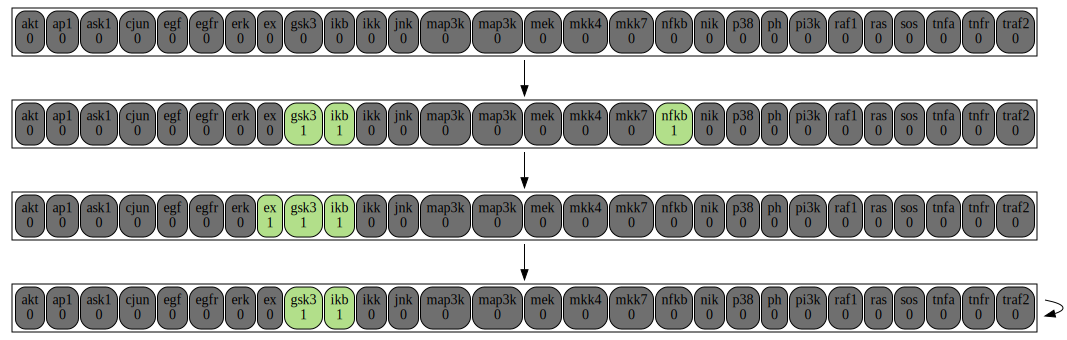

In [15]:
bsim_inactive = bn.boolean_simulation(initial_states=inactive_init_state)
bsim_inactive.plot_stg()

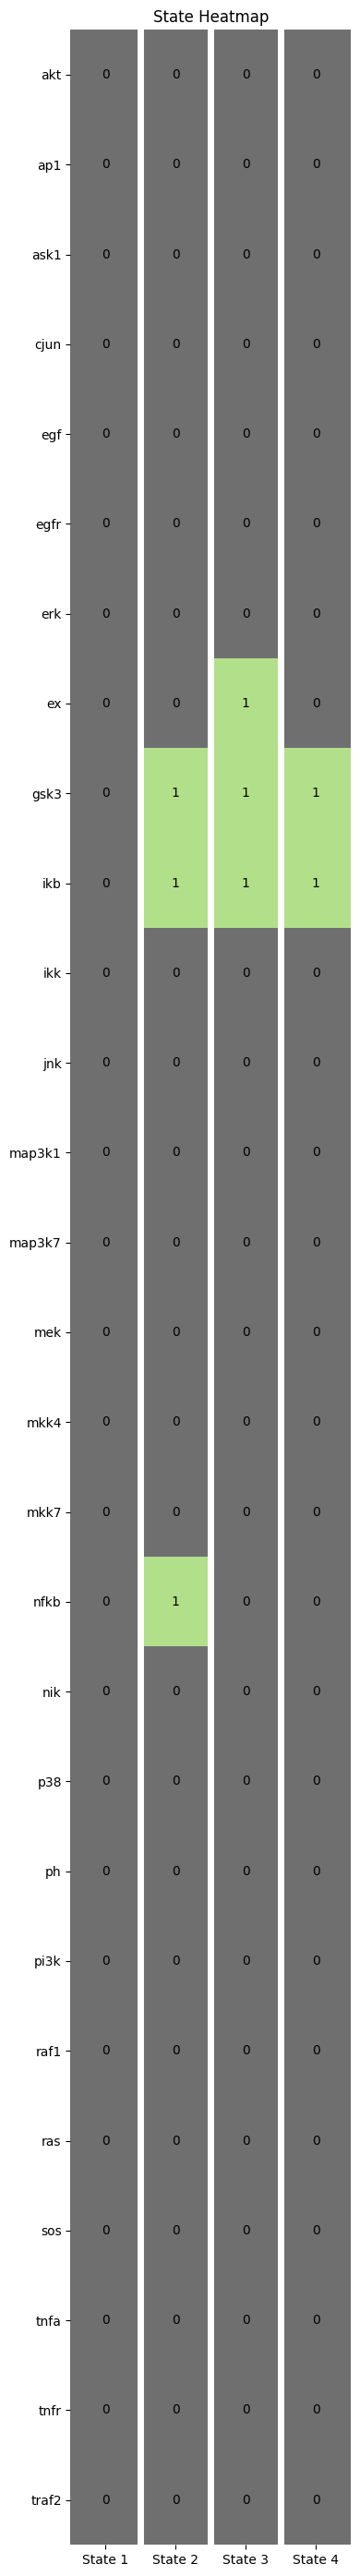

In [16]:
bsim_inactive.plot_state_space()

Compare the above plots to Figure 4A.

## Case (ii)

In [17]:
triggered_init_state = bn.inactivate_state(); 
triggered_init_state.set_node_state("egf", 1)
triggered_init_state.set_node_state("tnfa", 1)
triggered_init_state

BooleanStateSpace(network=<class 'booldog.network.BoolDogModel'> with 28 nodes, state_space=[{'akt': 0, 'ap1': 0, 'ask1': 0, 'cjun': 0, 'egf': 1, 'egfr': 0, 'erk': 0, 'ex': 0, 'gsk3': 0, 'ikb': 0, 'ikk': 0, 'jnk': 0, 'map3k1': 0, 'map3k7': 0, 'mek': 0, 'mkk4': 0, 'mkk7': 0, 'nfkb': 0, 'nik': 0, 'p38': 0, 'ph': 0, 'pi3k': 0, 'raf1': 0, 'ras': 0, 'sos': 0, 'tnfa': 1, 'tnfr': 0, 'traf2': 0}])

WARNING The state transition graph will consist of up to 2**28=268435456 states, depending on the initial states.


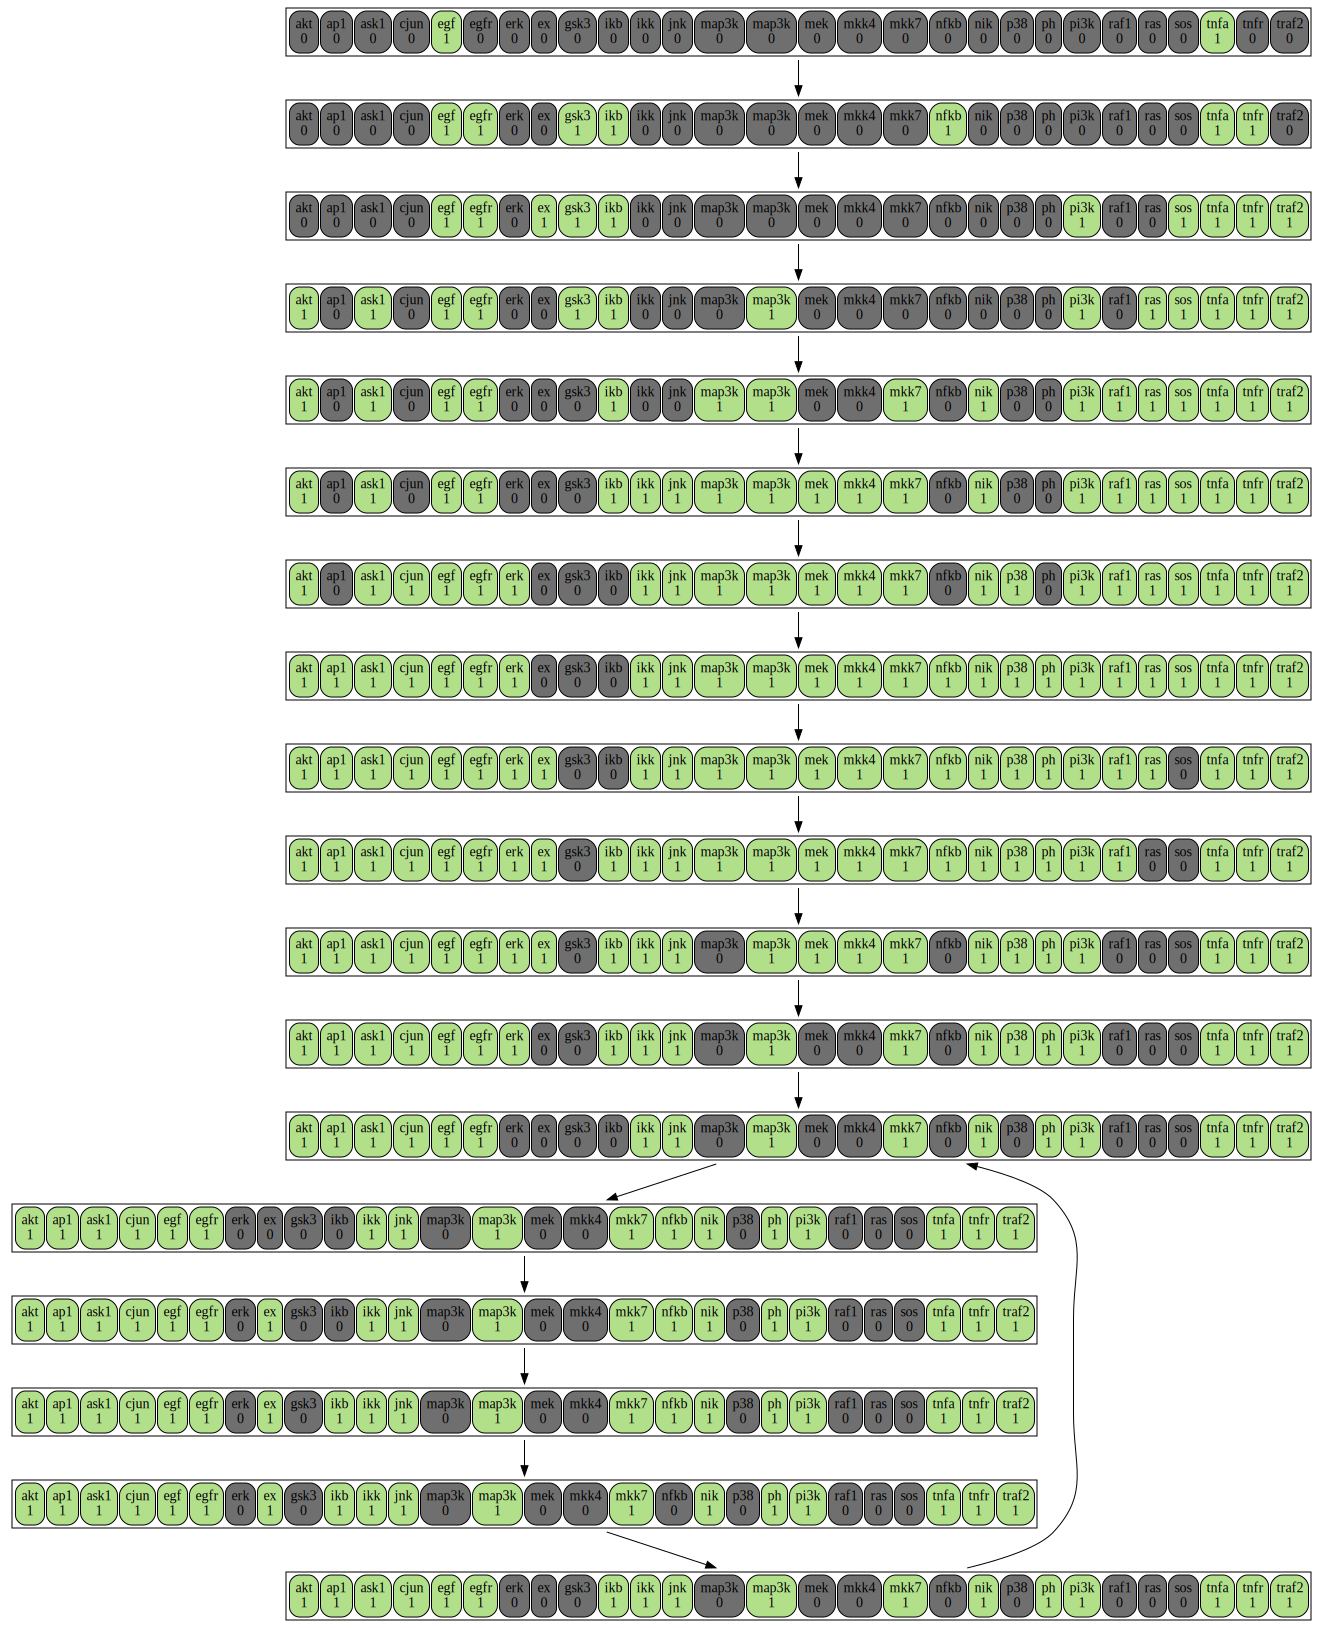

In [18]:
bsim_triggered = bn.boolean_simulation(initial_states=triggered_init_state)
bsim_triggered.plot_stg()

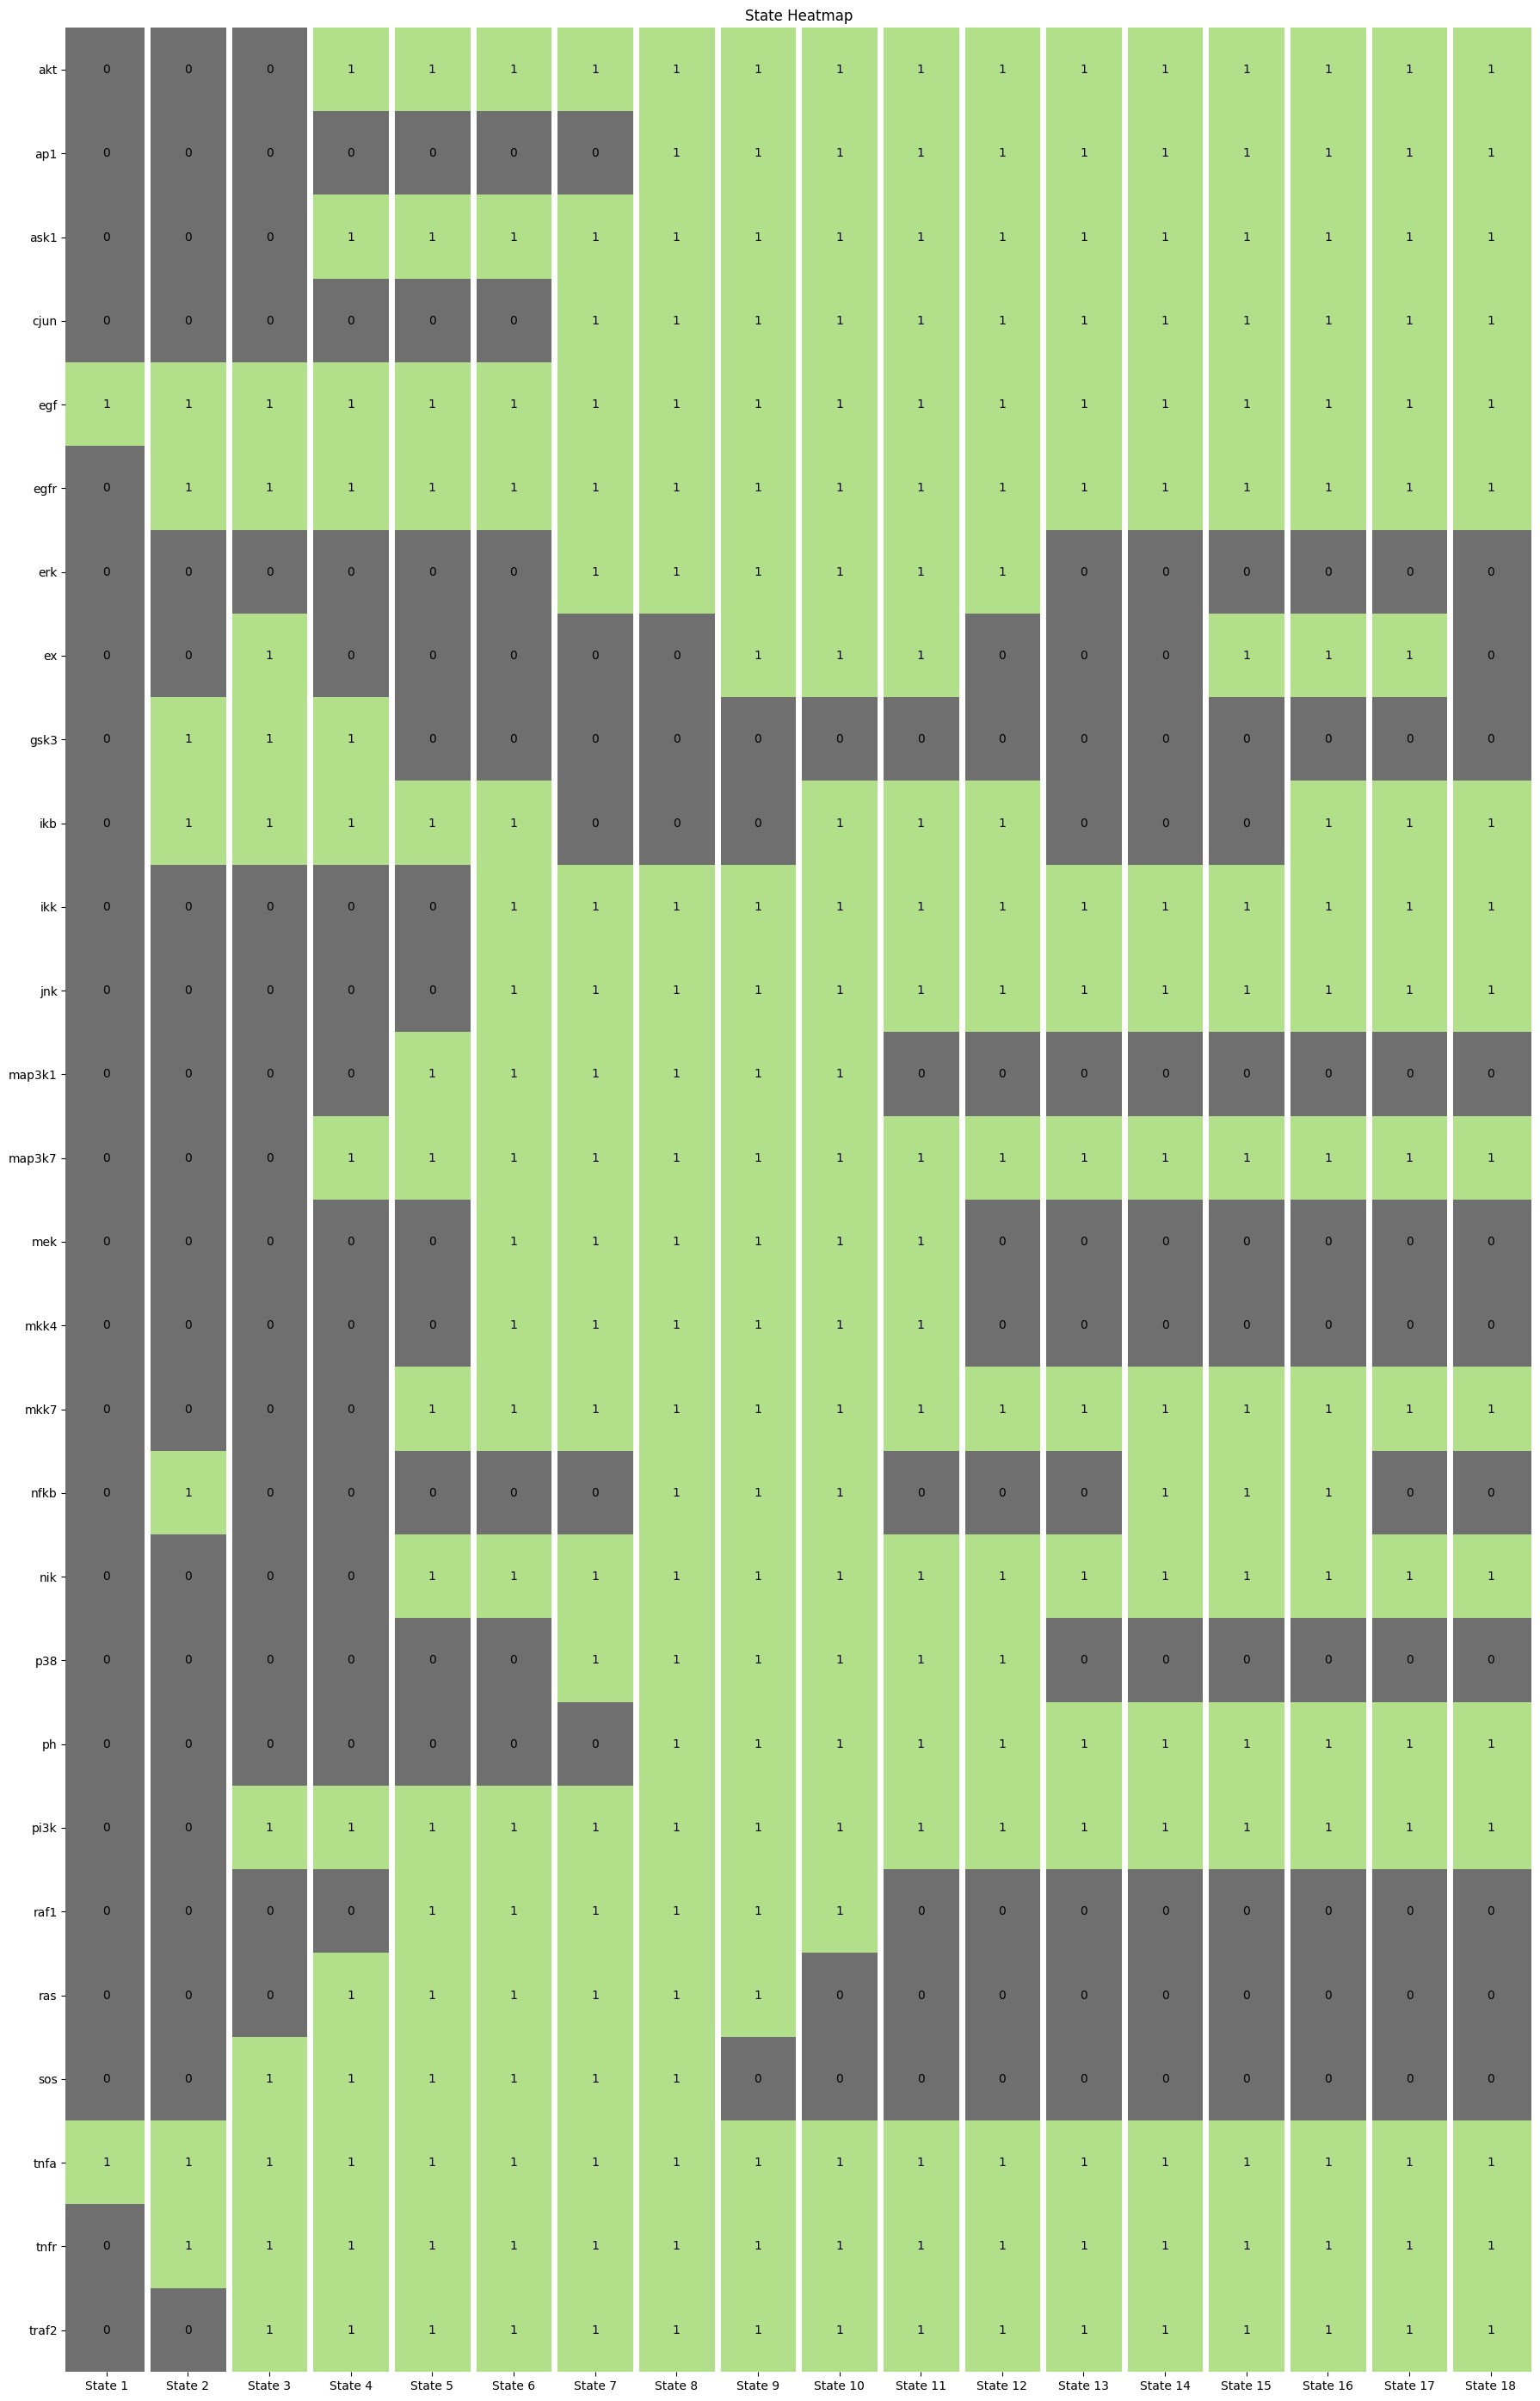

In [19]:
bsim_triggered.plot_state_space()

Compare the above plots to Figure 4B.

## Create animation from Boolean simulation

The animation is generated using Cytoscape, thus allowing a manual layout of the network as basis to the animation. 

In [20]:
gif = files_path / "triggered_ii.gif"

In [21]:
# bsim_triggered.make_animation(base_suid=main_suid, gif=gif)

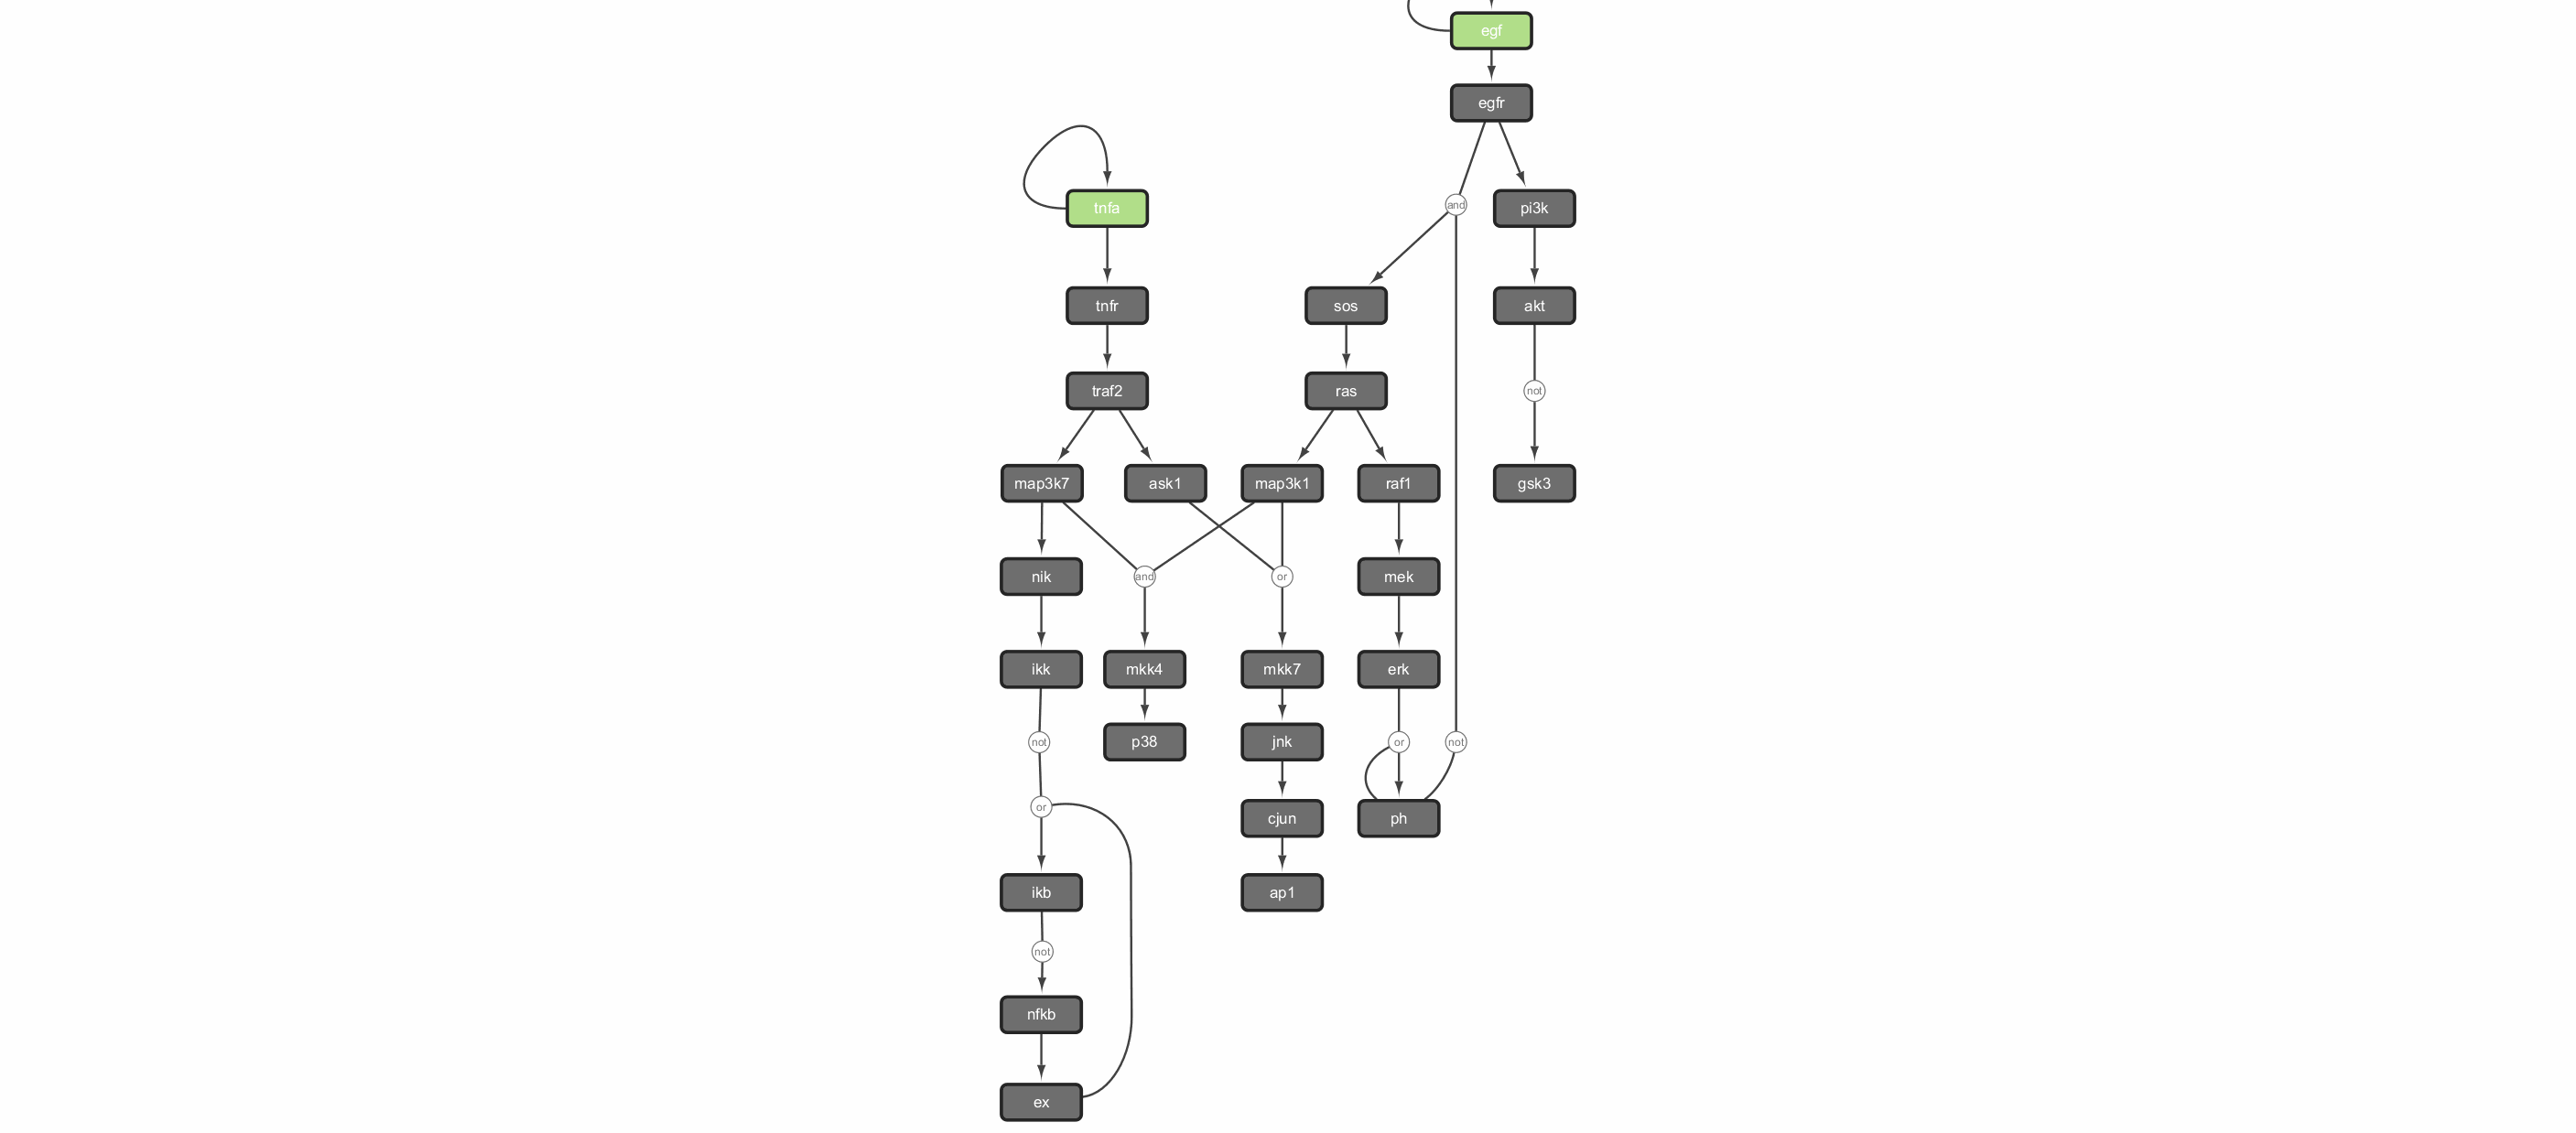

In [22]:
Image(gif)

# Semi-quantative ODE simulations

Using the ODFy schema:

INFO 2026-03-04 18:59:50,697 booldog.continuous.semi_quantitative:continuous_simulation Status: Generating ODE system ... 
INFO 2026-03-04 18:59:50,698 booldog.continuous.ode_factory:__init__ Creating ODE system for normalisedhillcube.
INFO 2026-03-04 18:59:50,701 booldog.continuous.semi_quantitative:continuous_simulation Status: ... done.
INFO 2026-03-04 18:59:50,702 booldog.continuous.semi_quantitative:continuous_simulation Status: Start
INFO 2026-03-04 18:59:50,928 booldog.continuous.semi_quantitative:continuous_simulation Status: End


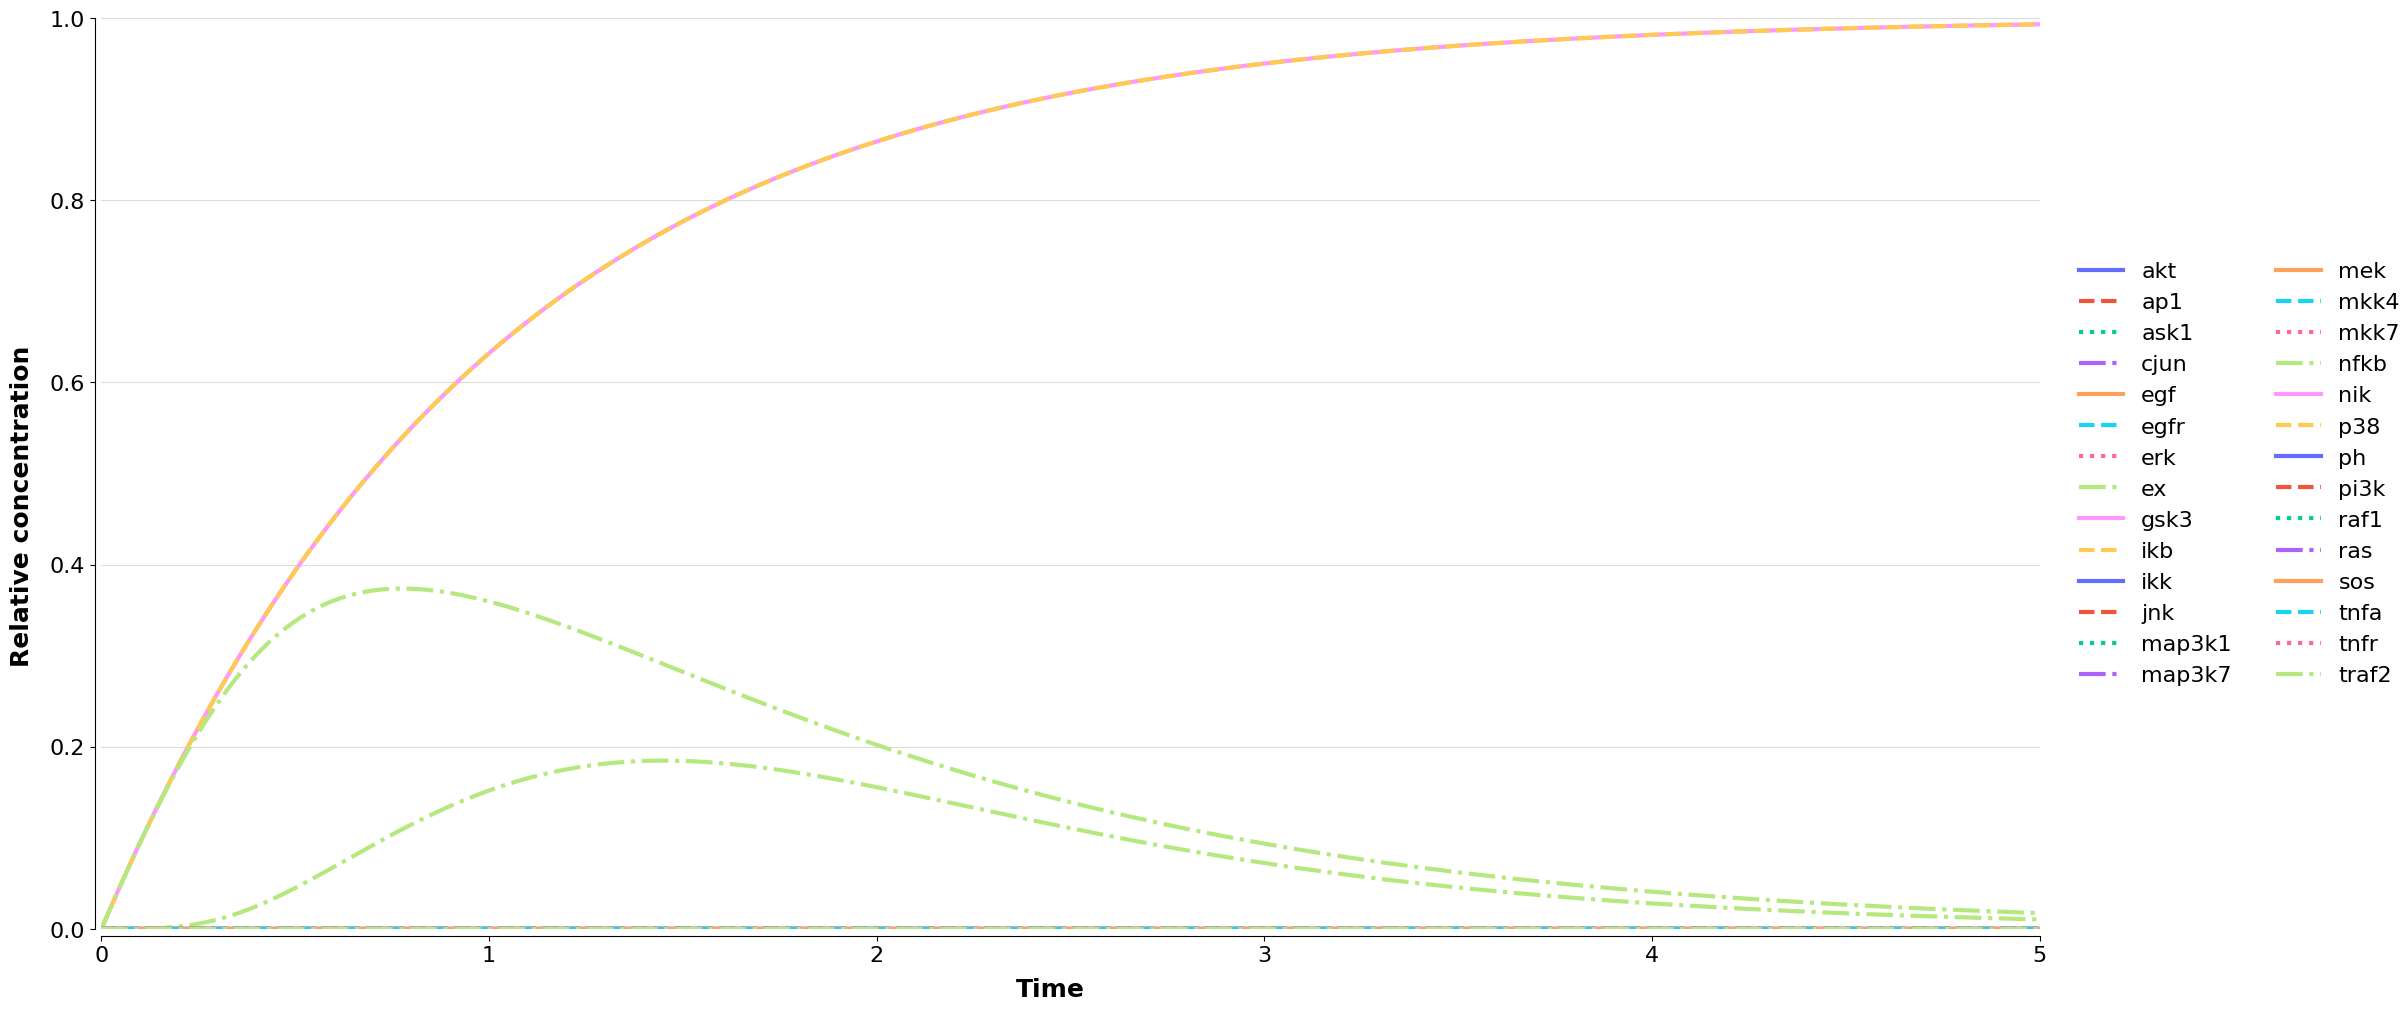

(<Figure size 2000x1000 with 1 Axes>, array([[<Axes: >]], dtype=object))

In [23]:
bn.continuous_simulation(
    t_max=5, 
    transform="normalisedhillcube"
).plot()

Using the SQUAD schema:

INFO 2026-03-04 18:59:51,441 booldog.continuous.semi_quantitative:continuous_simulation Status: Generating ODE system ... 
INFO 2026-03-04 18:59:51,442 booldog.continuous.ode_factory:__init__ Creating ODE system for squad.
/home/cbleker/research/NIB/boolean-modelling/BoolDoG/booldog/continuous/ode_factory.py:463: RuntimeWarning: divide by zero encountered in divide
  self._a1 = (1 + self._A1) / self._A1
/home/cbleker/research/NIB/boolean-modelling/BoolDoG/booldog/continuous/ode_factory.py:465: RuntimeWarning: divide by zero encountered in divide
  self._b1 = (1 + self._B1) / self._B1
INFO 2026-03-04 18:59:51,445 booldog.continuous.semi_quantitative:continuous_simulation Status: ... done.
INFO 2026-03-04 18:59:51,445 booldog.continuous.semi_quantitative:continuous_simulation Status: Start
/home/cbleker/research/NIB/boolean-modelling/BoolDoG/booldog/continuous/ode_factory.py:479: RuntimeWarning: invalid value encountered in multiply
  a = ensure_ndarray(self._a1 * a_x / (1+a_x))
/home/cb

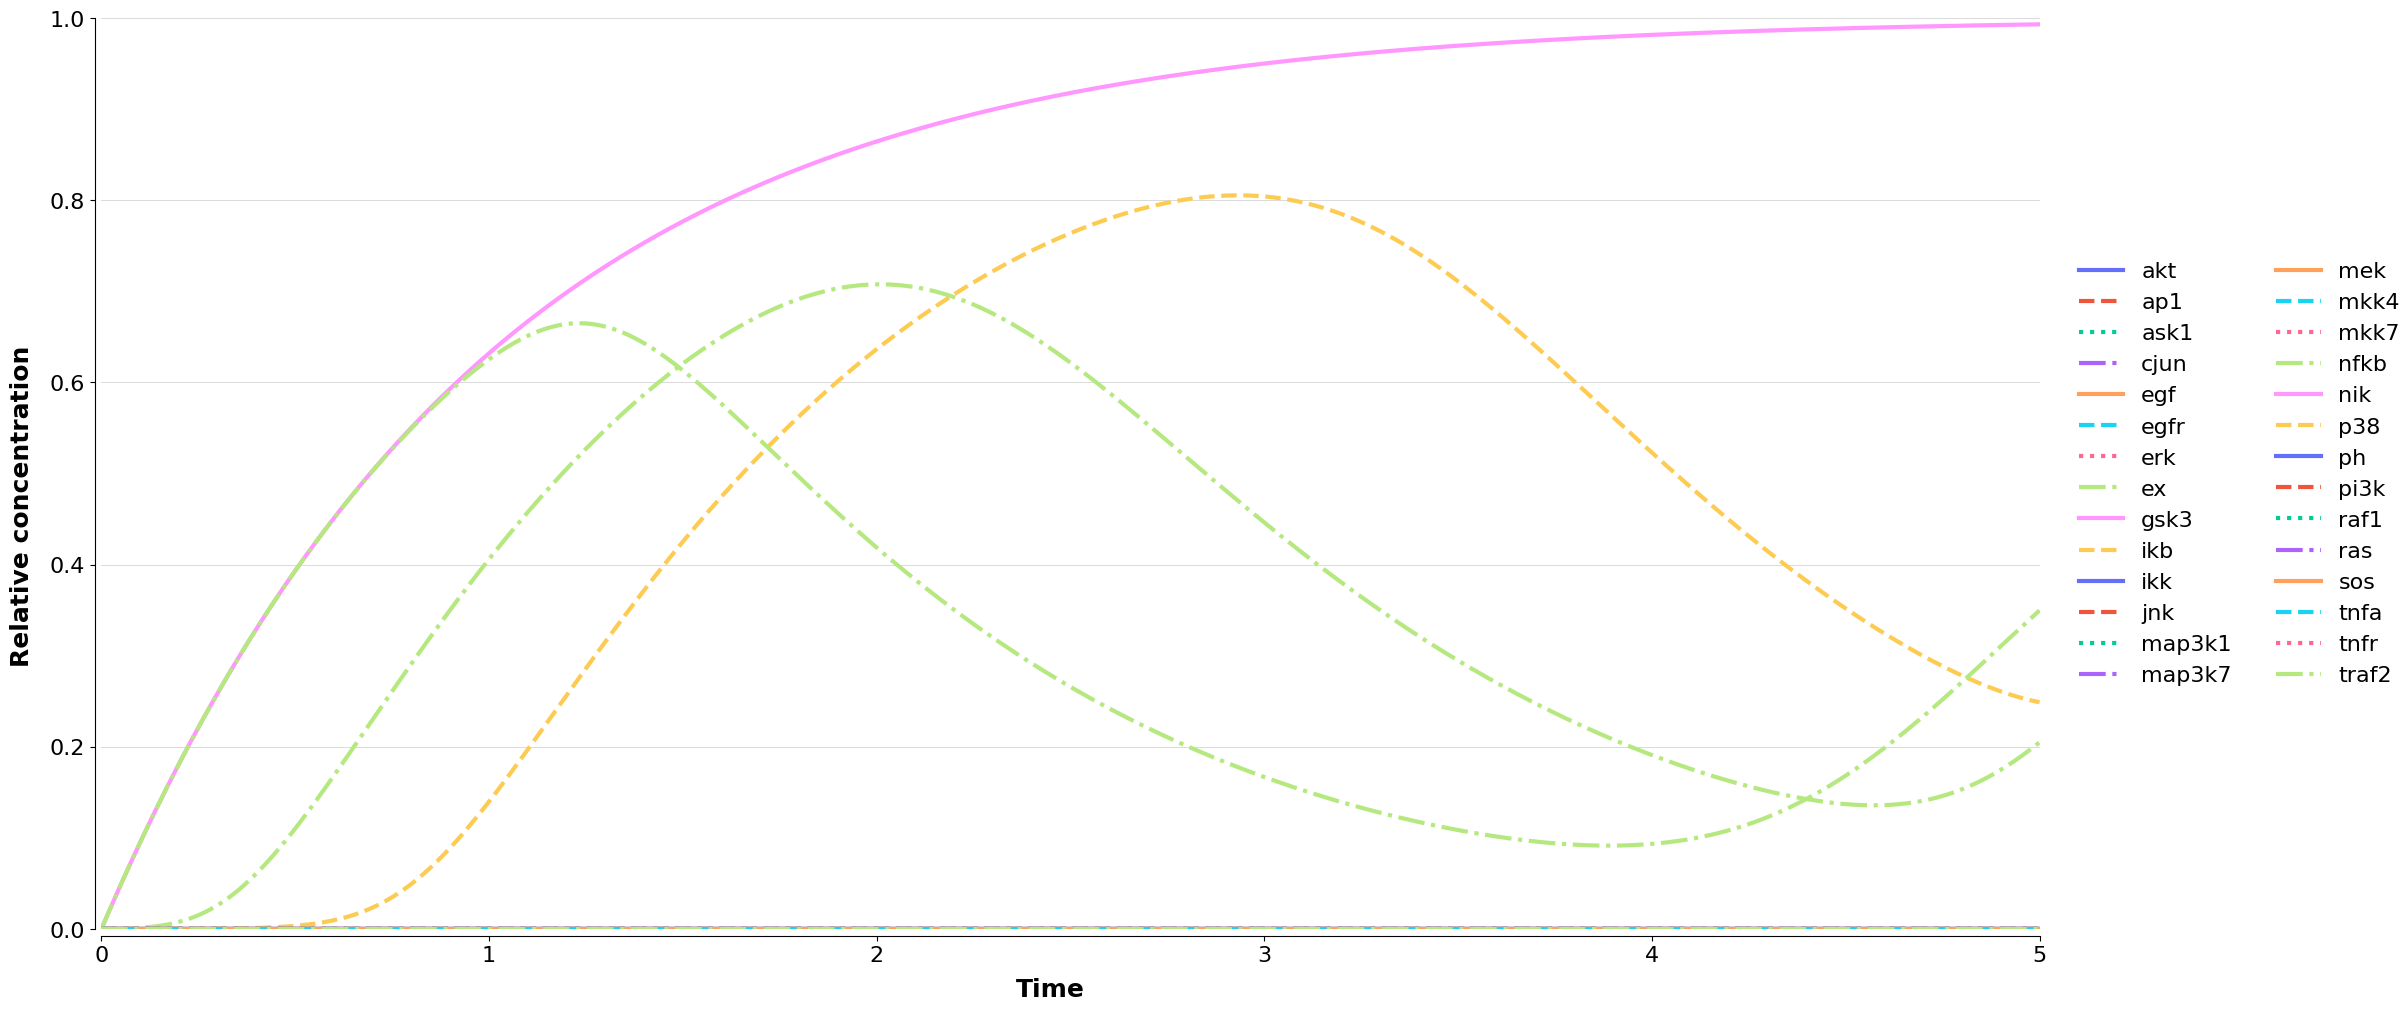

(<Figure size 2000x1000 with 1 Axes>, array([[<Axes: >]], dtype=object))

In [24]:
bn.continuous_simulation(
    t_max=5, 
    transform="squad"
).plot()

# Continous simulation with an event

In [25]:
# use the inactive boolean simulation steady state as the initial state
last_state = list(bsim_inactive.stg.nodes())[-1]; last_state

'0000000011000000000000000000'

INFO 2026-03-04 18:59:52,121 booldog.continuous.semi_quantitative:continuous_simulation Status: Generating ODE system ... 
INFO 2026-03-04 18:59:52,122 booldog.continuous.ode_factory:__init__ Creating ODE system for normalisedhillcube.
INFO 2026-03-04 18:59:52,124 booldog.continuous.semi_quantitative:continuous_simulation Status: ... done.
INFO 2026-03-04 18:59:52,126 booldog.continuous.semi_quantitative:continuous_simulation Status: Start
INFO 2026-03-04 18:59:52,189 booldog.continuous.semi_quantitative:continuous_simulation Status: Event at 2.0:
       egf -> 1.00 (duration  0)
      tnfa -> 1.00 (duration  0)

INFO 2026-03-04 18:59:52,858 booldog.continuous.semi_quantitative:continuous_simulation Status: End


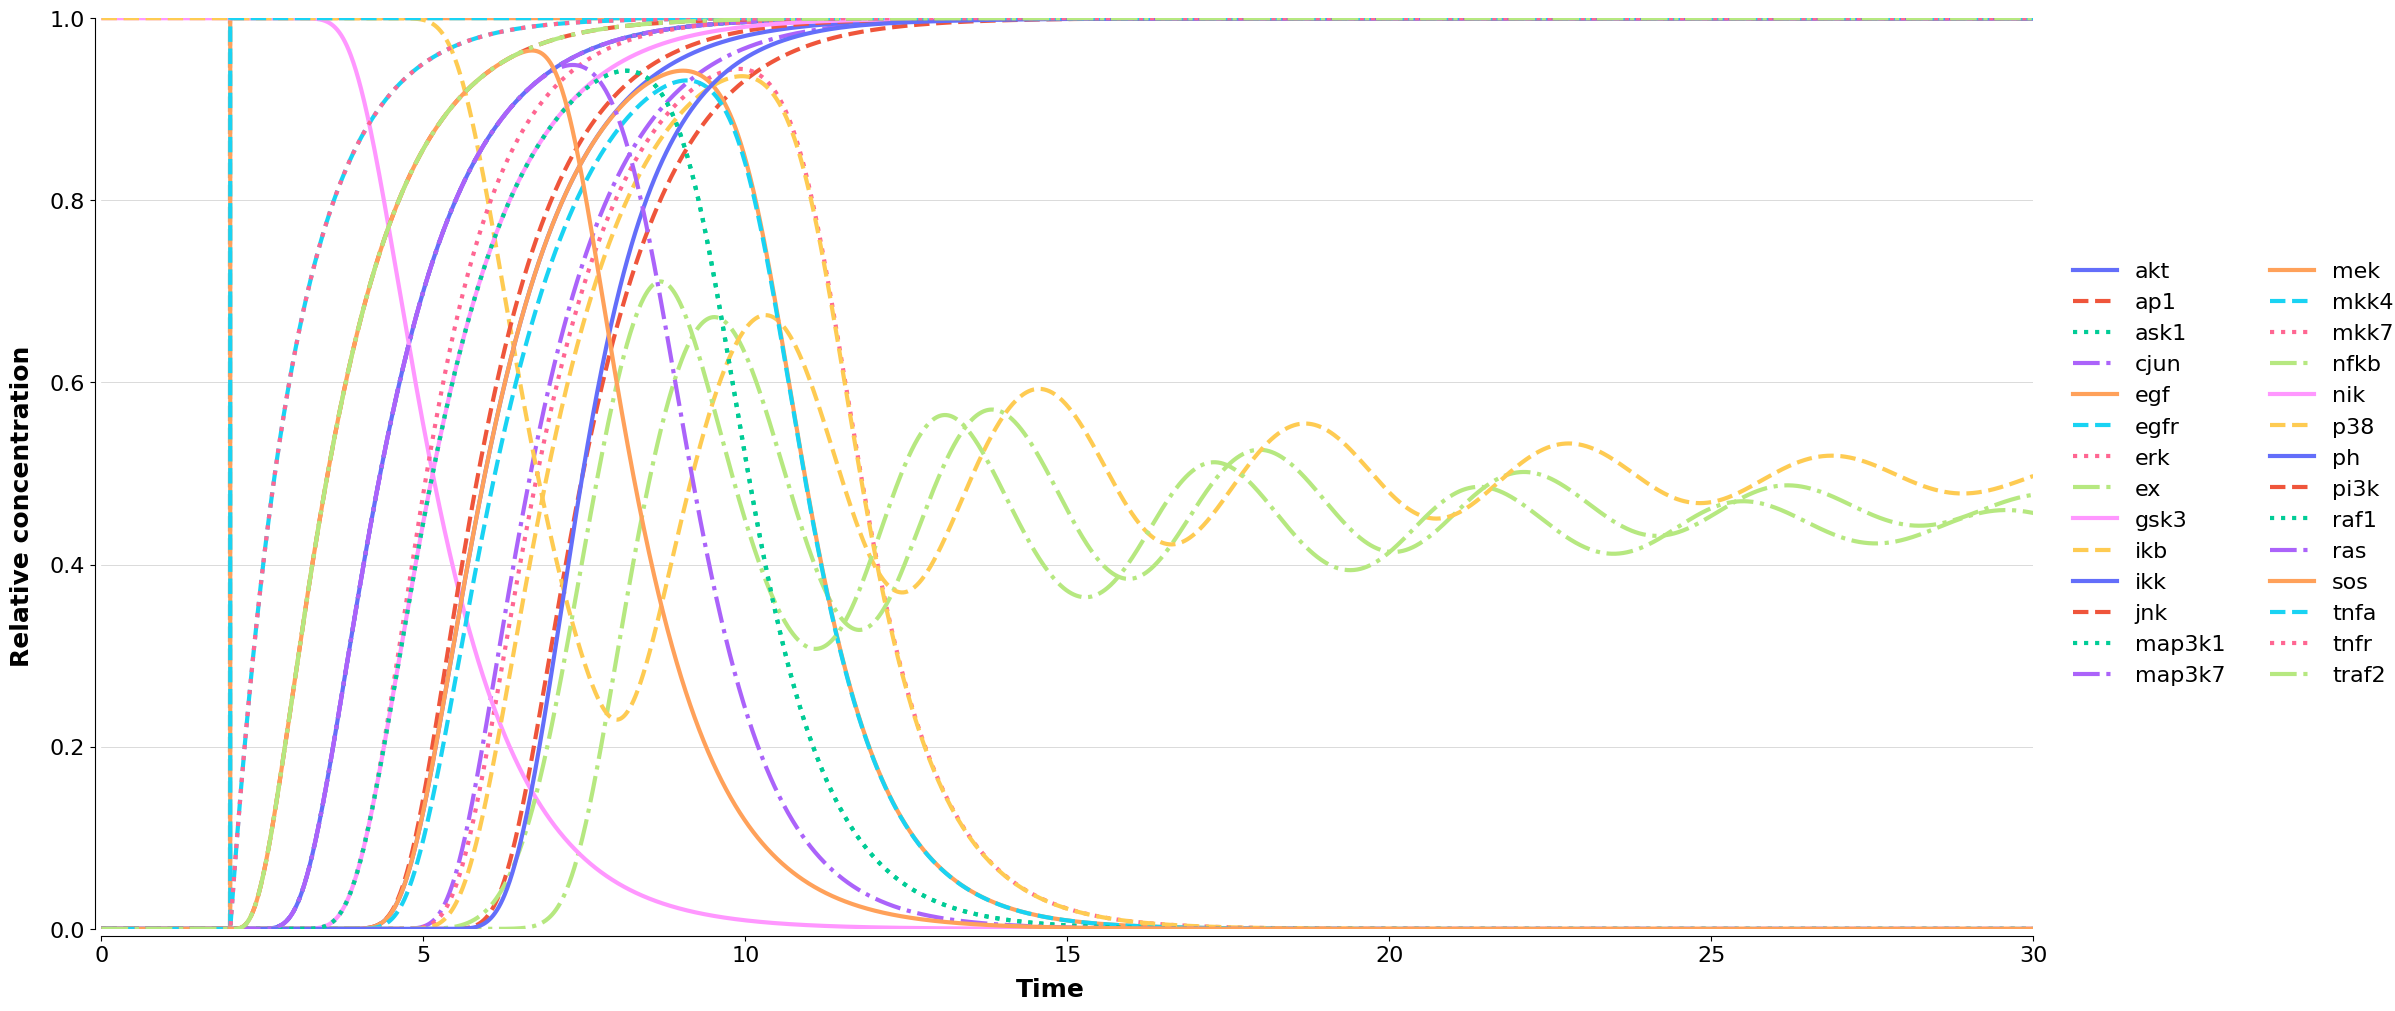

(<Figure size 2000x1000 with 1 Axes>, array([[<Axes: >]], dtype=object))

In [26]:
simulation = bn.continuous_simulation(
    t_max=30,
    initial_state={n:s for n, s in zip(bn.node_ids, last_state)}, 
    transform="normalisedhillcube",
    node_events = [
        {'time':2, 'node':'egf', 'value':1},
        {'time':2, 'node':'tnfa', 'value':1}
    ]
)
simulation.plot()

The simulation results can be exported to a tsv file:

In [27]:
simulation.export?

Signature: simulation.export(outfile, decimals=5)
Docstring:
Export simulation results to a file.

Parameters
----------
outfile : str or Path
    Path to the output file. The file will be created if it does not
    exist. If the file already exists, it will be overwritten.

decimals : int
    Number of decimals to round the output values to. Default is 5.

Notes
-----
The output file will contain:
    - nodelist
    - ODE transform
    - ODE parameters
    - node_events
    - timepoints
    - solution/y

The output will be tab-separated and can be read into a pandas DataFrame.
If you want to use `pandas` to read the file, you can use the following code:
df = pd.read_csv(outfile, sep=" ")
File:      ~/research/NIB/boolean-modelling/BoolDoG/booldog/simulation_result/continuous_result.py
Type:      method

Lets save the plot to a SVG:

# Modify the Boolean network

Possible modifications include:
- update/change a node rule
- remove a node
- add a node


A node cannot be removed if other nodes depend on it (i.e. it occurs in
their update logic). To remove such a node, either also remove all of
its dependants, or first update the logic rule of its dependants to
remove dependency.


In [28]:
bn.nodes['ph'].rule

'( ph | erk )'

In [29]:
bn.update_node('ph', 'erk')
bn.remove_nodes(['ex', 'ikb', 'nfkb'])
bn.add_node("new", "ph | mkk4")

In [30]:
print('ph -->', bn.nodes['ph'].rule)
print('new -->', bn.nodes['new'].rule)

ph --> erk
new --> ph | mkk4


In [31]:
# Lists all modifications to the model
bn.modifications

[Modification(type=ModificationTypes.UPDATE, node_id=ph, rule=erk),
 Modification(type=ModificationTypes.REMOVE, node_id=['ex', 'ikb', 'nfkb'], rule=None),
 Modification(type=ModificationTypes.ADD, node_id=new, rule=ph | mkk4)]

In [32]:
bn.to_cytoscape(title="modified")

Applying default style...
Applying preferred layout


11235

# Export the Boolean network

## BNET format

In [33]:
# show
print(bn.to_bnet())

targets, factors
erk, ( mek )
ikk, ( nik )
gsk3, ( !akt )
ask1, ( traf2 )
ras, ( sos )
egf, egf
egfr, ( egf )
traf2, ( tnfr )
map3k1, ( ras )
tnfr, ( tnfa )
ap1, ( cjun )
mek, ( raf1 )
mkk4, ( map3k7 & map3k1 )
tnfa, tnfa
raf1, ( ras )
map3k7, ( traf2 )
mkk7, ( ask1 | map3k1 )
cjun, ( jnk )
sos, ( egfr & !ph )
jnk, ( mkk7 )
pi3k, ( egfr )
p38, ( mkk4 )
akt, ( pi3k )
ph, erk
nik, ( map3k7 )
new, ph | mkk4



In [34]:
# save to a file
bn.to_bnet(files_path / f"{bn.modelinfo.identifier}-modified-bnet.txt")

INFO 2026-03-04 18:59:54,137 booldog.io.bnet:write_bnet Wrote model as bnet to files/MODEL1411240000-modified-bnet.txt


## SBML-qual

In [35]:
# save to SBML-qual
bn.to_sbmlqual(files_path / f"{bn.modelinfo.identifier}-modified-sbmlqual.xml")

INFO 2026-03-04 18:59:54,159 booldog.io.sbml:write Wrote Network as a Boolean model in SBML-qual to files/MODEL1411240000-modified-sbmlqual.xml


# As a NetworkX network

In NetworkX the underlying interaction network can be analysed using common graph theoretical approaches. 

In [36]:
g = bn.to_networkx(as_logic_circuit=False)

In [37]:
g.in_degree()

InDegreeView({'akt': 1, 'ap1': 1, 'ask1': 1, 'cjun': 1, 'egf': 1, 'egfr': 1, 'erk': 1, 'gsk3': 1, 'ikk': 1, 'jnk': 1, 'map3k1': 1, 'map3k7': 1, 'mek': 1, 'mkk4': 2, 'mkk7': 2, 'nik': 1, 'p38': 1, 'ph': 1, 'pi3k': 1, 'raf1': 1, 'ras': 1, 'sos': 2, 'tnfa': 1, 'tnfr': 1, 'traf2': 1, 'new': 2})

In [38]:
import networkx as nx

In [39]:
nx.connectivity.average_node_connectivity(g)

0.2753846153846154

In [40]:
nx.centrality.degree_centrality(g)

{'akt': 0.08,
 'ap1': 0.04,
 'ask1': 0.08,
 'cjun': 0.08,
 'egf': 0.12,
 'egfr': 0.12,
 'erk': 0.08,
 'gsk3': 0.04,
 'ikk': 0.04,
 'jnk': 0.08,
 'map3k1': 0.12,
 'map3k7': 0.12,
 'mek': 0.08,
 'mkk4': 0.16,
 'mkk7': 0.12,
 'nik': 0.08,
 'p38': 0.04,
 'ph': 0.12,
 'pi3k': 0.08,
 'raf1': 0.08,
 'ras': 0.12,
 'sos': 0.12,
 'tnfa': 0.12,
 'tnfr': 0.08,
 'traf2': 0.12,
 'new': 0.08}